In [1]:
"""

DCGAN (Deep Convolutional GAN)
"Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks" (Radford et al., 2015)

"""

'\n\nDCGAN (Deep Convolutional GAN)\n"Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks" (Radford et al., 2015)\n\n'

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-faces-64x64-for-generative-models' dataset.
Path to dataset files: /kaggle/input/cats-faces-64x64-for-generative-models


In [4]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002

In [6]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


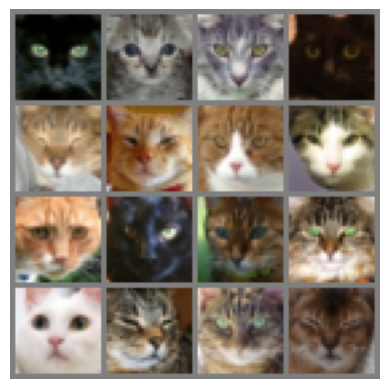

In [7]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [8]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z):
        return self.network(z)

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [9]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 32, use_norm=False), # 32 -> 16
            DownBlock(32, 64),                # 16 -> 8
            DownBlock(64, 128),               # 8 -> 4

            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
            nn.Sigmoid()
        )

        self.network.apply(init_weights)

    def forward(self, image):
        return self.network(image)

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_norm=True):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1, bias=not use_norm),
            nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [10]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 1.0, 0.02)
        torch.nn.init.zeros_(m.bias)

In [11]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [12]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.99))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.99))

In [13]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: 0.4346  G_loss: 2.2467  D(x): 0.770  D(G(z)): 0.142:   4%|▍         | 199/5000 [00:55<22:31,  3.55it/s]

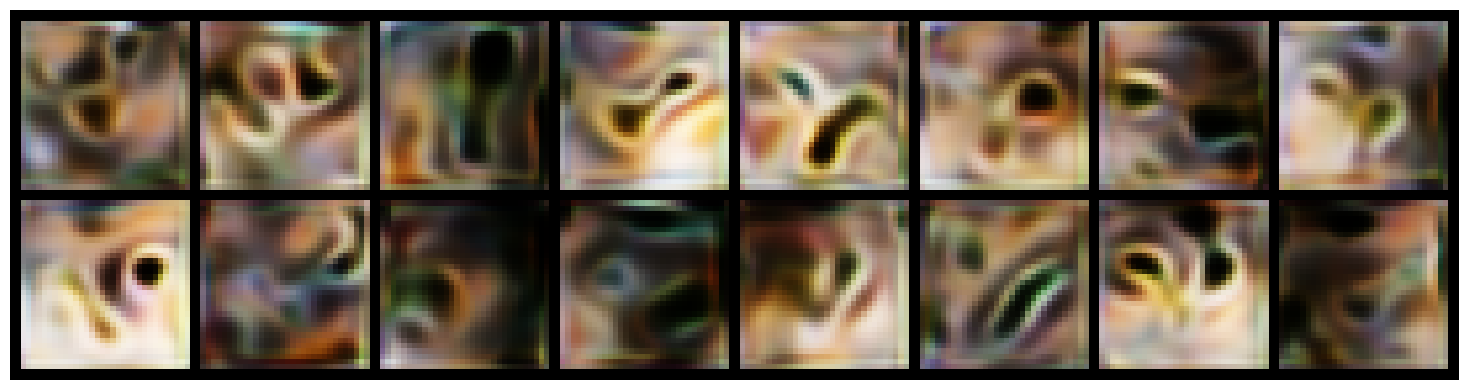

D_loss: 0.6221  G_loss: 2.4108  D(x): 0.842  D(G(z)): 0.118:   8%|▊         | 399/5000 [01:47<20:06,  3.81it/s]

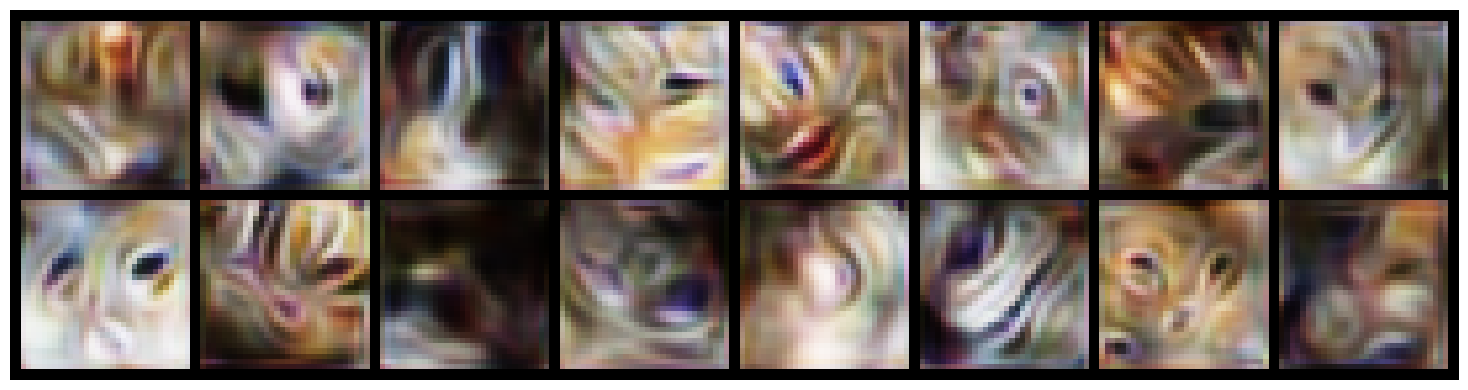

D_loss: 0.5809  G_loss: 1.8589  D(x): 0.813  D(G(z)): 0.206:  12%|█▏        | 598/5000 [02:22<07:29,  9.80it/s]

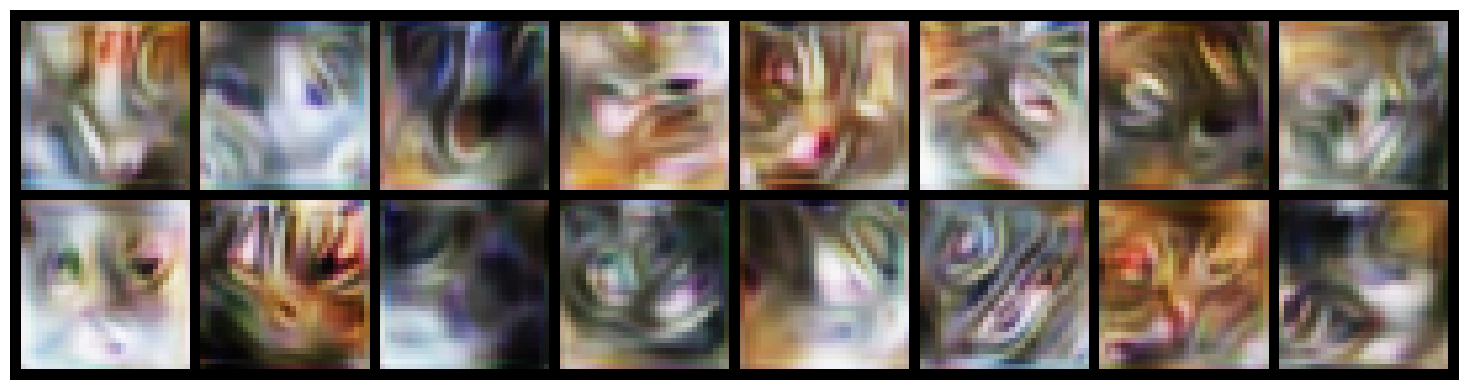

D_loss: 0.6037  G_loss: 1.4895  D(x): 0.810  D(G(z)): 0.299:  16%|█▌        | 799/5000 [02:41<06:15, 11.20it/s]

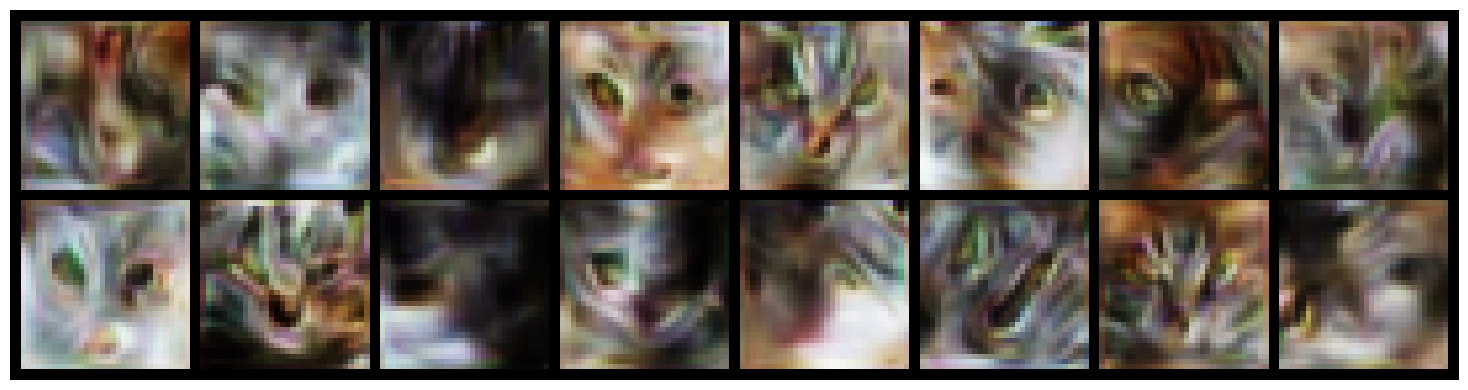

D_loss: 0.7856  G_loss: 1.7035  D(x): 0.701  D(G(z)): 0.232:  20%|█▉        | 998/5000 [03:01<06:03, 11.01it/s]

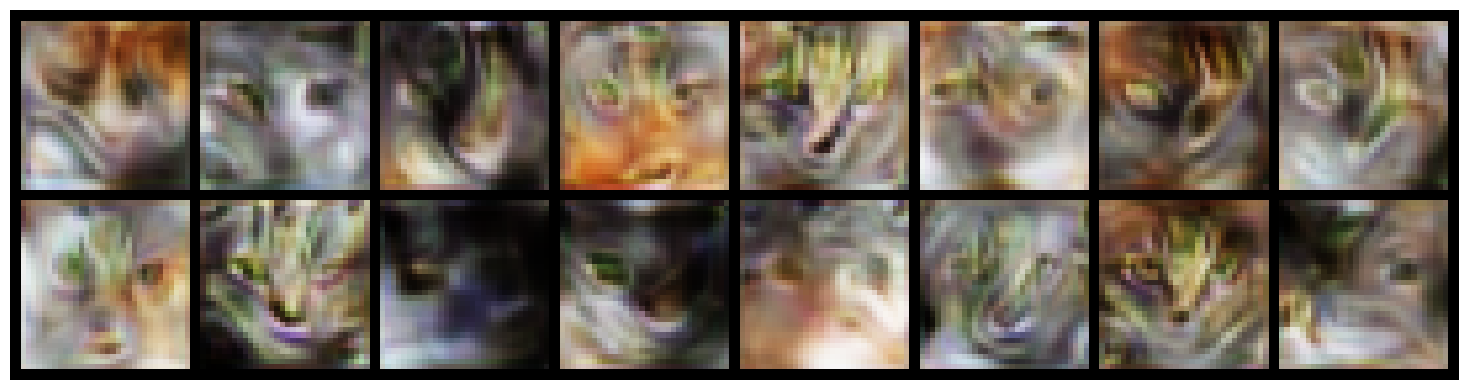

D_loss: 0.5937  G_loss: 1.7962  D(x): 0.814  D(G(z)): 0.213:  24%|██▍       | 1199/5000 [03:20<05:43, 11.07it/s]

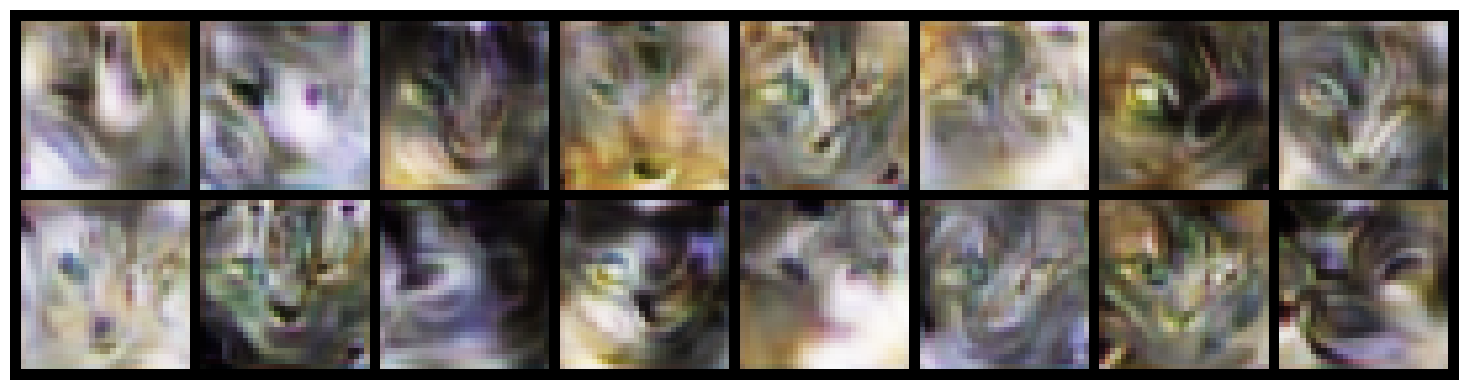

D_loss: 0.8238  G_loss: 1.6810  D(x): 0.735  D(G(z)): 0.233:  28%|██▊       | 1398/5000 [03:39<05:28, 10.97it/s]

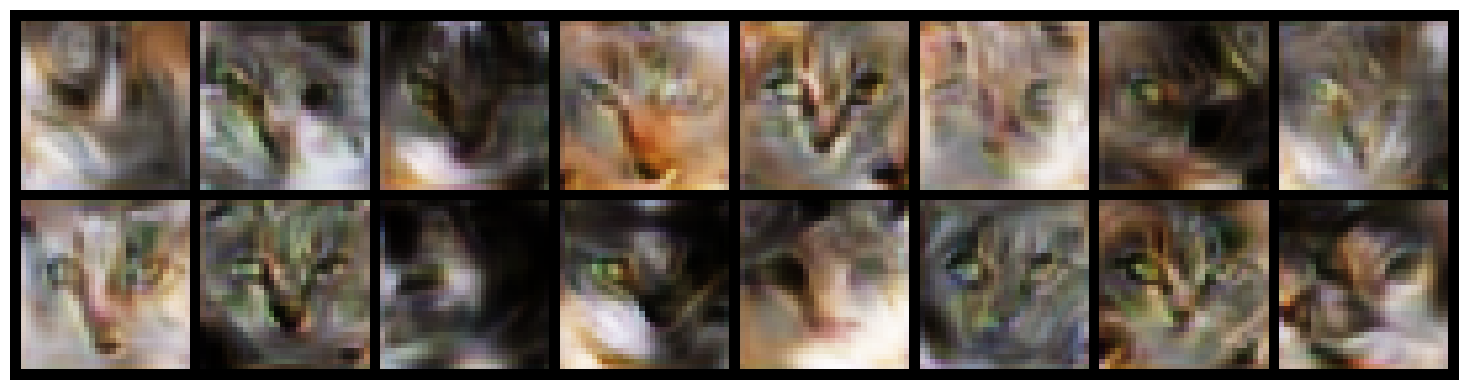

D_loss: 0.7211  G_loss: 2.3357  D(x): 0.845  D(G(z)): 0.138:  32%|███▏      | 1599/5000 [03:58<06:10,  9.18it/s]

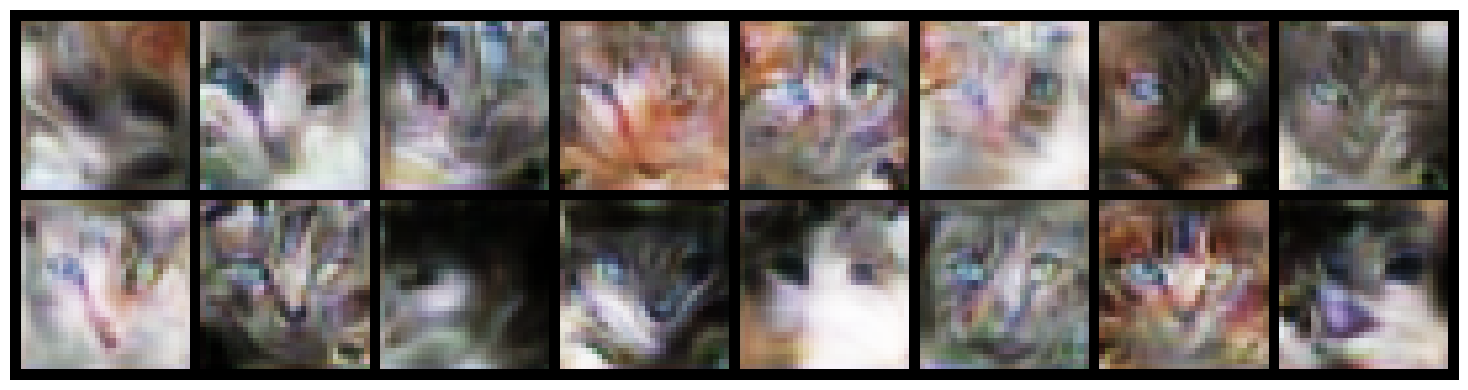

D_loss: 0.7831  G_loss: 1.8772  D(x): 0.664  D(G(z)): 0.187:  36%|███▌      | 1798/5000 [04:17<04:59, 10.69it/s]

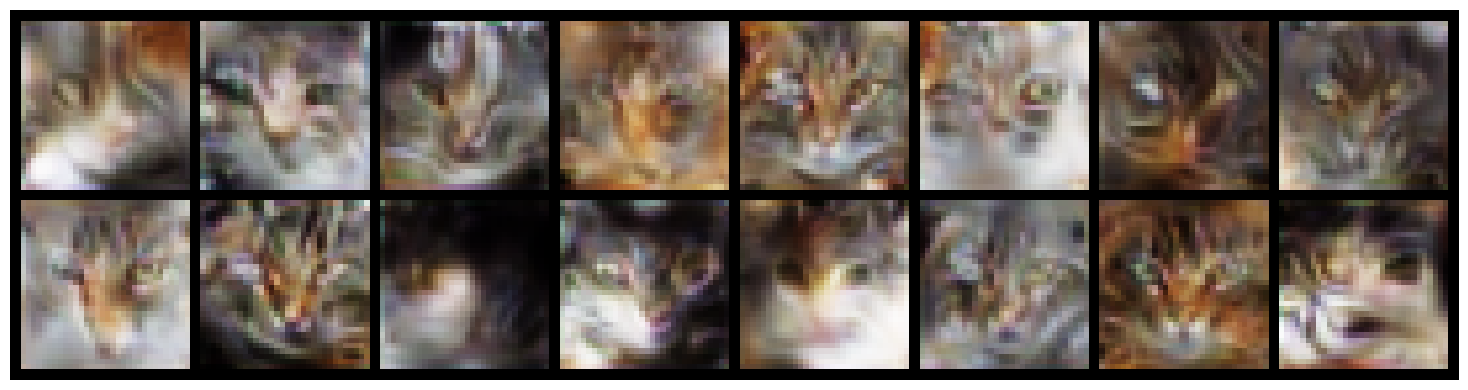

D_loss: 0.8867  G_loss: 1.8072  D(x): 0.654  D(G(z)): 0.215:  40%|███▉      | 1998/5000 [04:37<04:42, 10.61it/s]

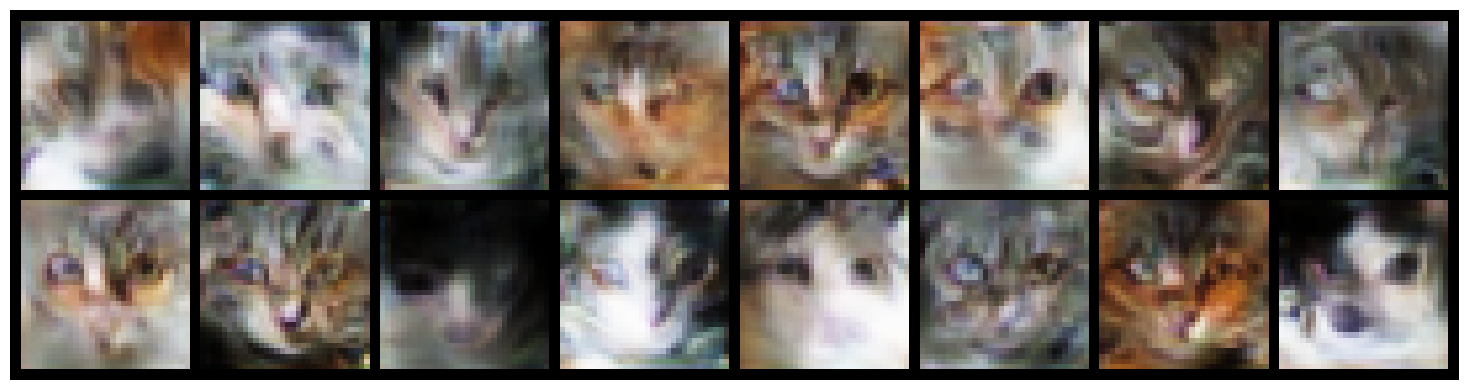

D_loss: 0.7211  G_loss: 1.5914  D(x): 0.711  D(G(z)): 0.283:  44%|████▍     | 2198/5000 [04:56<04:15, 10.97it/s]

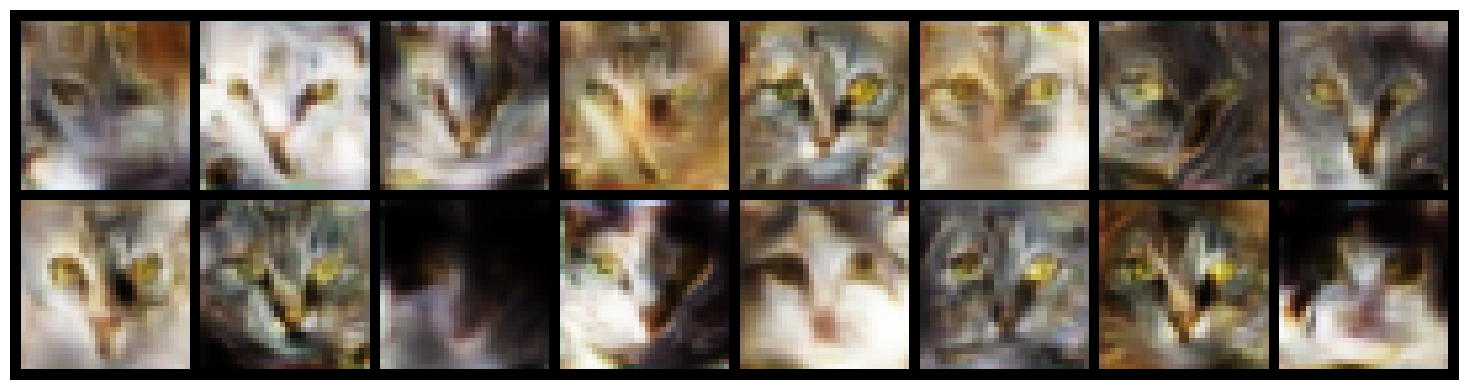

D_loss: 0.7079  G_loss: 1.9400  D(x): 0.742  D(G(z)): 0.200:  48%|████▊     | 2398/5000 [05:15<03:54, 11.08it/s]

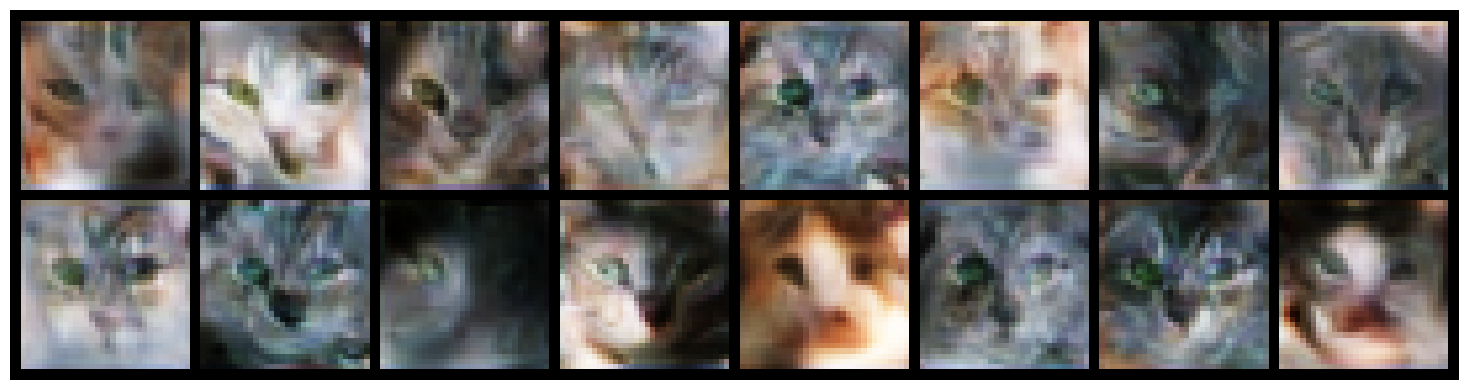

D_loss: 0.8686  G_loss: 1.8672  D(x): 0.846  D(G(z)): 0.208:  52%|█████▏    | 2599/5000 [05:34<03:53, 10.28it/s]

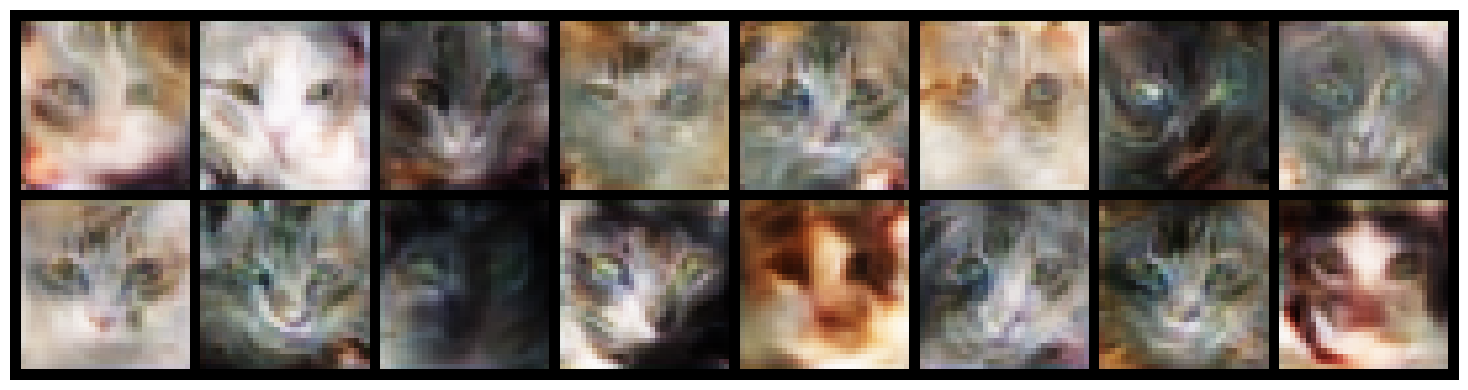

D_loss: 0.6503  G_loss: 2.4504  D(x): 0.751  D(G(z)): 0.124:  56%|█████▌    | 2798/5000 [05:53<03:19, 11.05it/s]

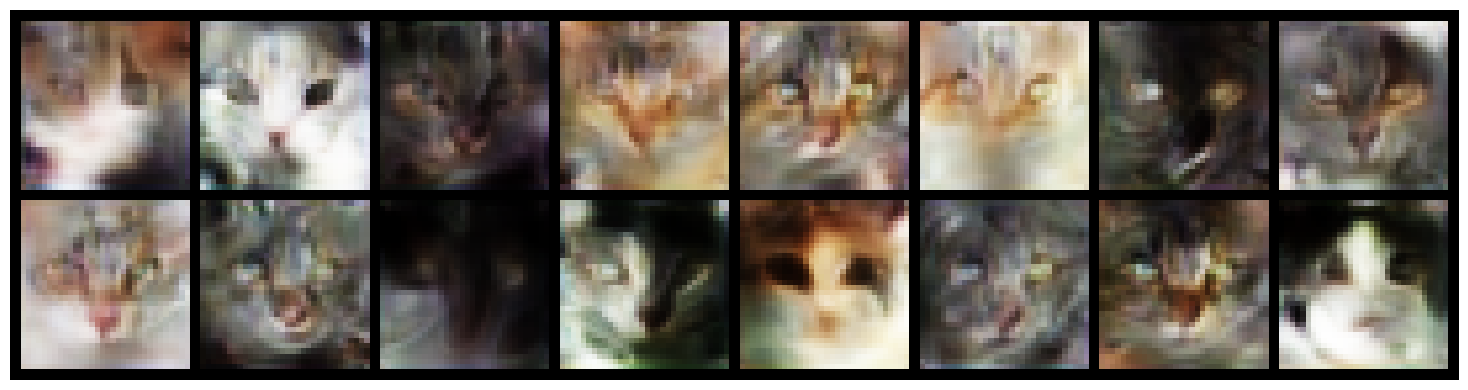

D_loss: 0.7316  G_loss: 1.6483  D(x): 0.655  D(G(z)): 0.267:  60%|█████▉    | 2999/5000 [06:13<03:49,  8.70it/s]

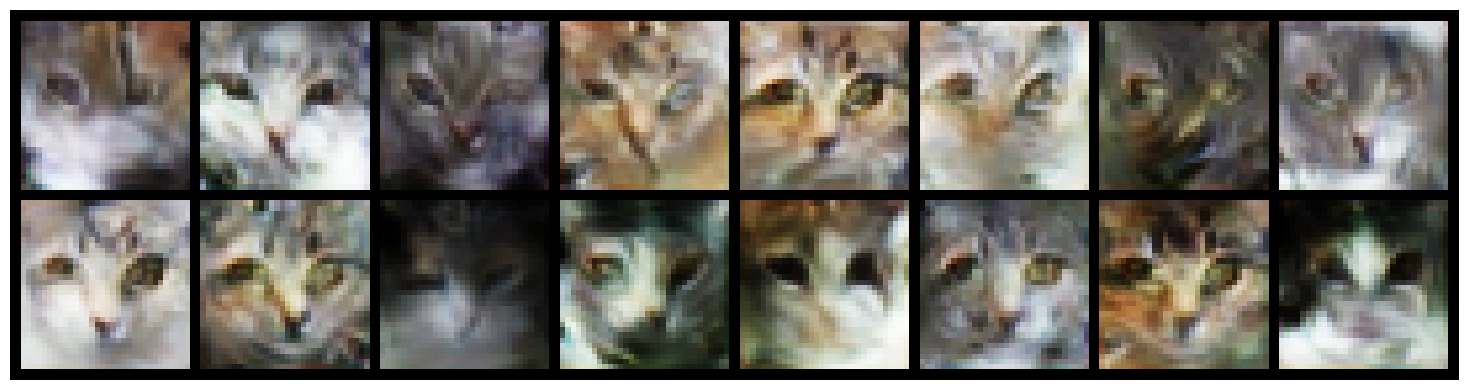

D_loss: 0.7313  G_loss: 1.4536  D(x): 0.653  D(G(z)): 0.291:  64%|██████▍   | 3198/5000 [06:32<02:45, 10.92it/s]

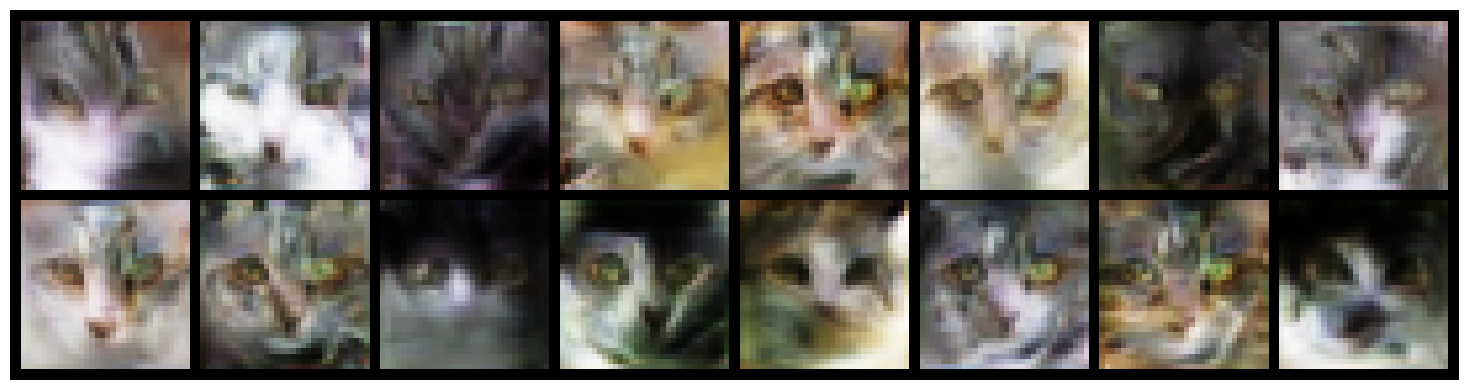

D_loss: 0.7721  G_loss: 2.5562  D(x): 0.696  D(G(z)): 0.124:  68%|██████▊   | 3399/5000 [06:52<02:33, 10.42it/s]

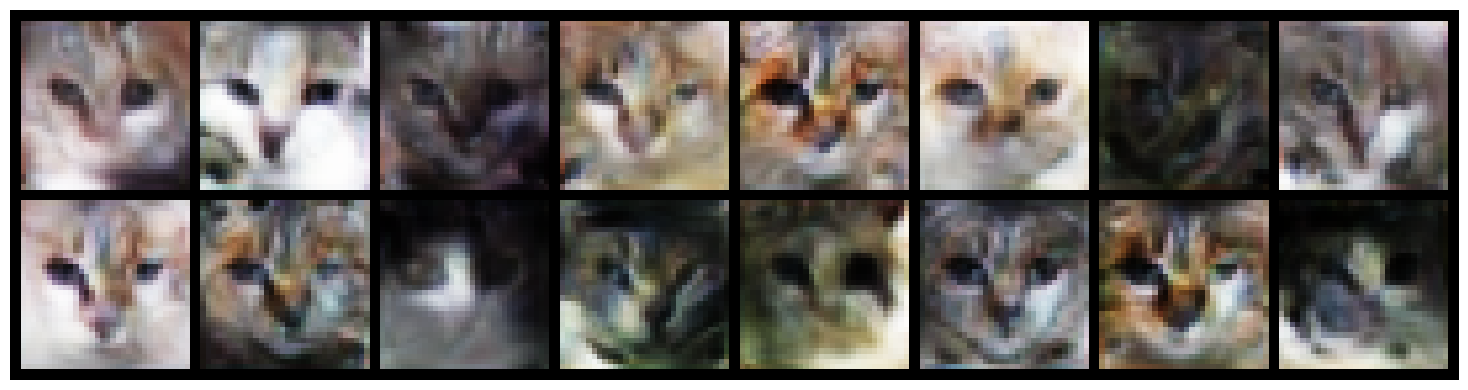

D_loss: 0.6305  G_loss: 2.6473  D(x): 0.840  D(G(z)): 0.117:  72%|███████▏  | 3598/5000 [07:11<02:11, 10.68it/s]

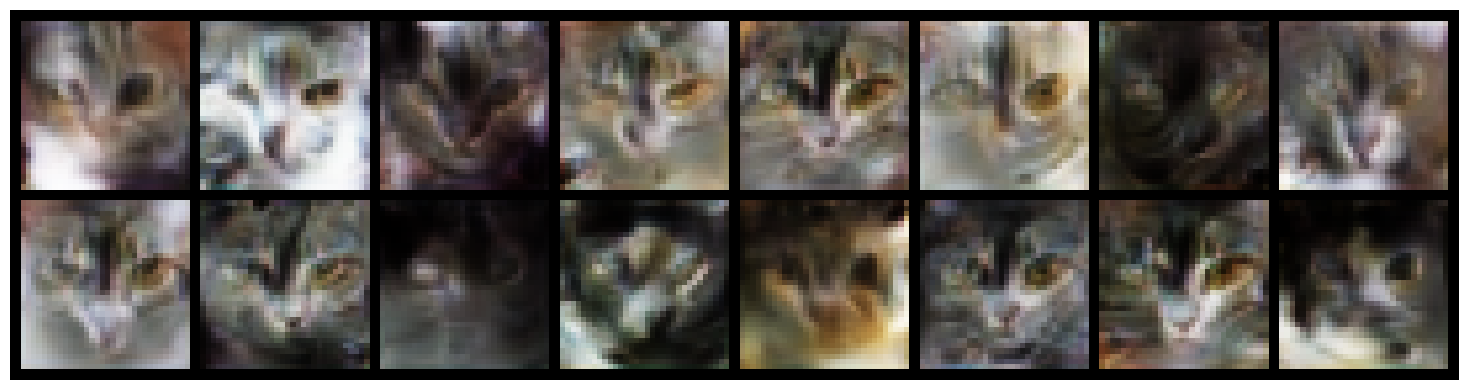

D_loss: 0.8587  G_loss: 2.6923  D(x): 0.671  D(G(z)): 0.140:  76%|███████▌  | 3798/5000 [07:31<01:53, 10.63it/s]

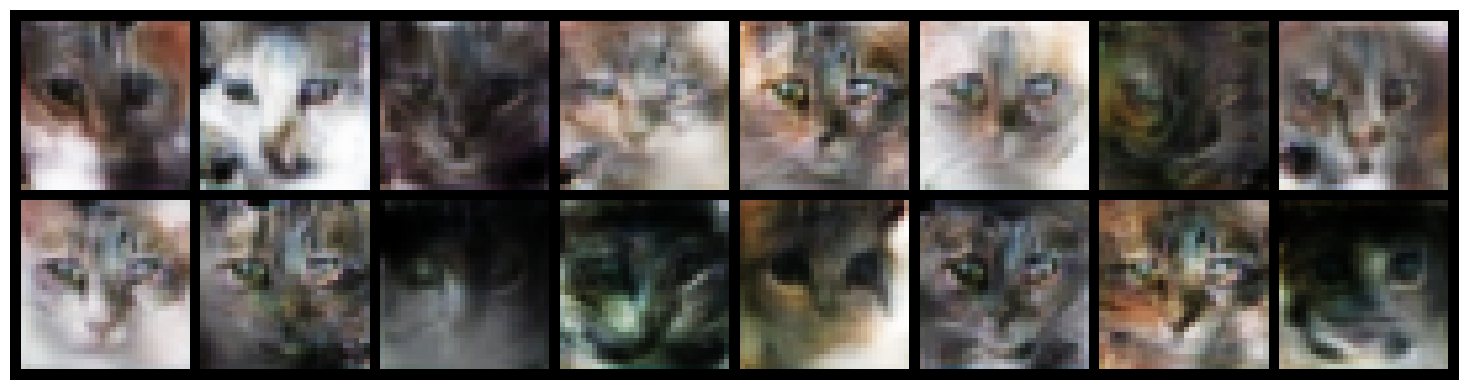

D_loss: 0.5875  G_loss: 2.4306  D(x): 0.747  D(G(z)): 0.129:  80%|███████▉  | 3999/5000 [07:50<01:44,  9.58it/s]

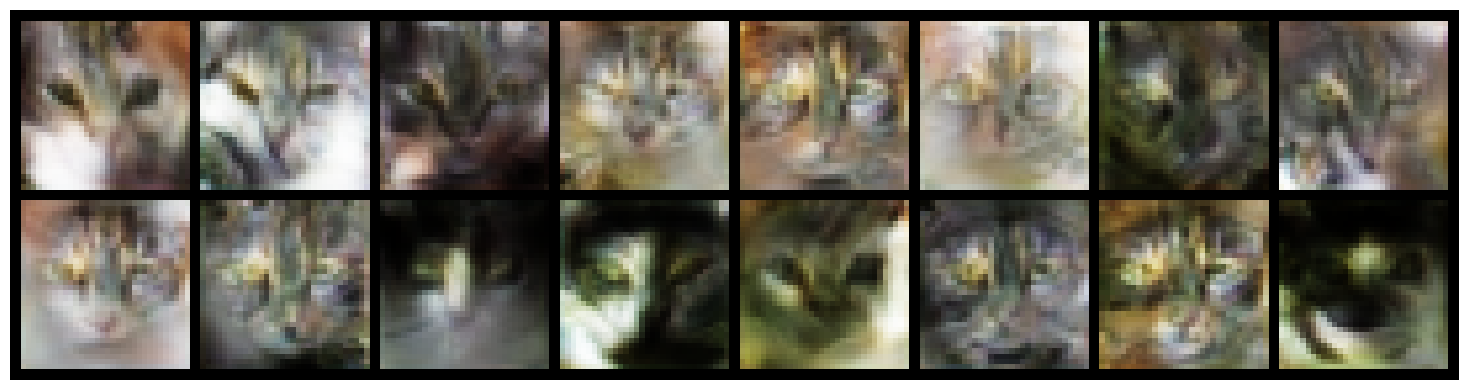

D_loss: 0.7242  G_loss: 2.3398  D(x): 0.783  D(G(z)): 0.167:  84%|████████▍ | 4198/5000 [08:10<01:15, 10.68it/s]

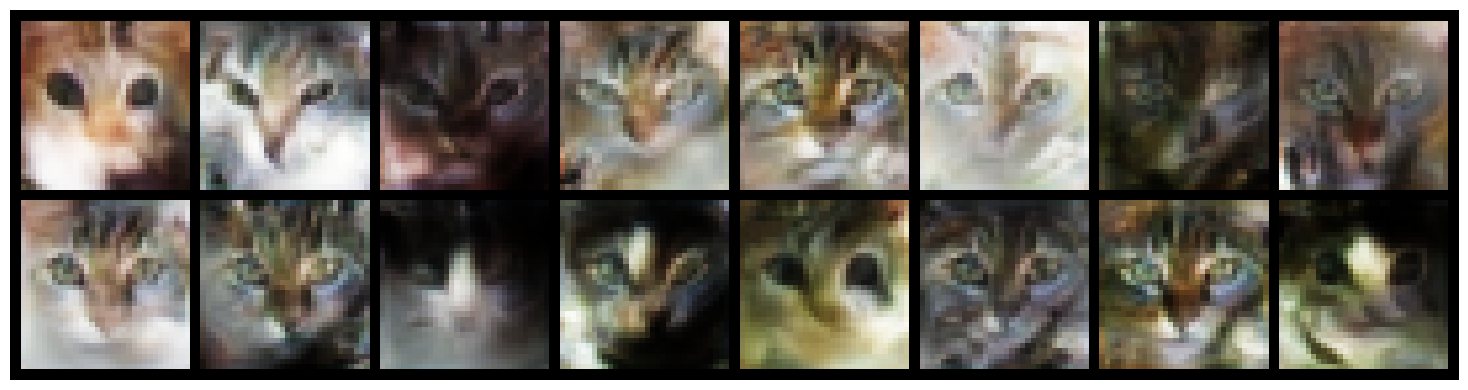

D_loss: 0.5708  G_loss: 2.1223  D(x): 0.751  D(G(z)): 0.179:  88%|████████▊ | 4398/5000 [08:30<01:00, 10.03it/s]

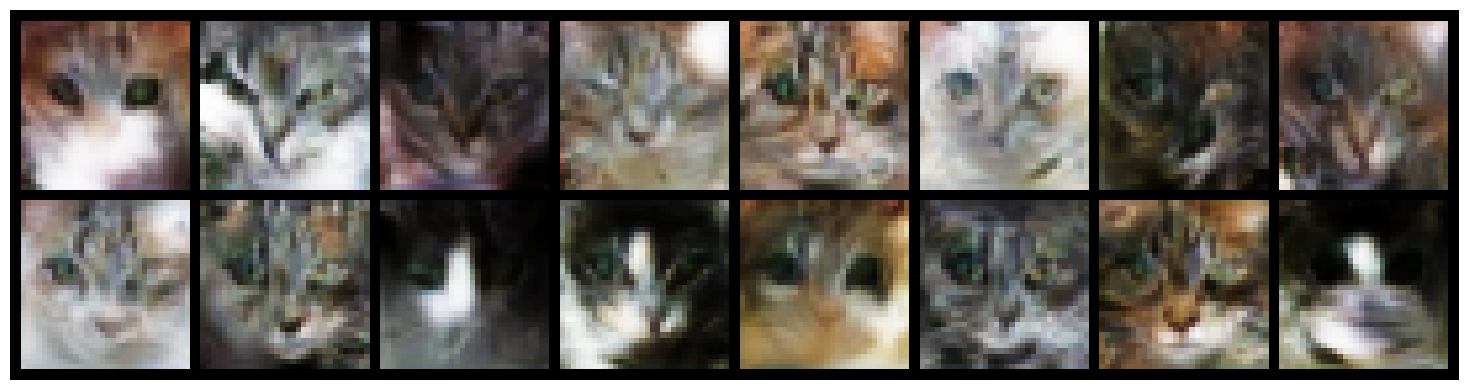

D_loss: 0.7039  G_loss: 1.8065  D(x): 0.754  D(G(z)): 0.238:  92%|█████████▏| 4598/5000 [08:50<00:37, 10.76it/s]

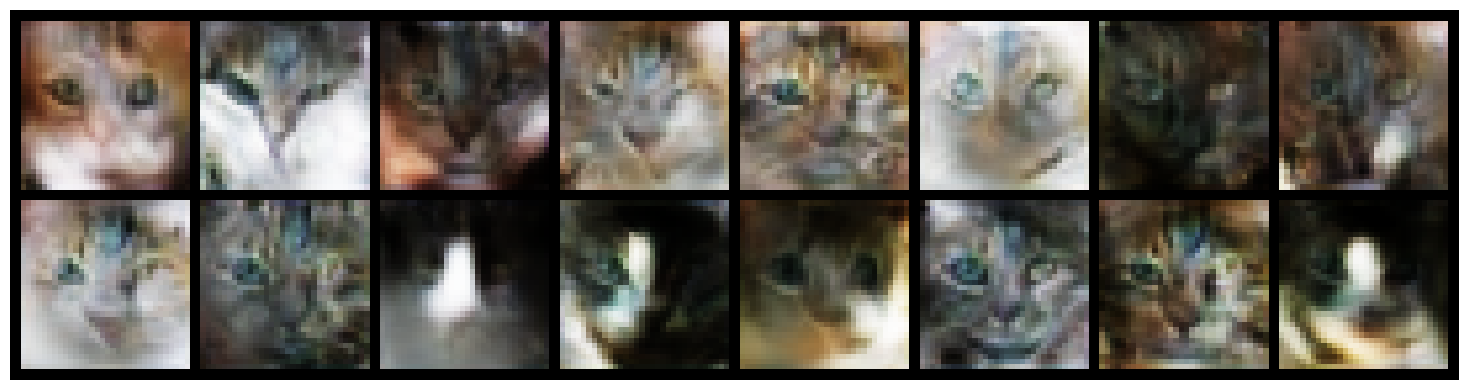

D_loss: 0.7165  G_loss: 2.2974  D(x): 0.755  D(G(z)): 0.154:  96%|█████████▌| 4799/5000 [09:10<00:18, 10.61it/s]

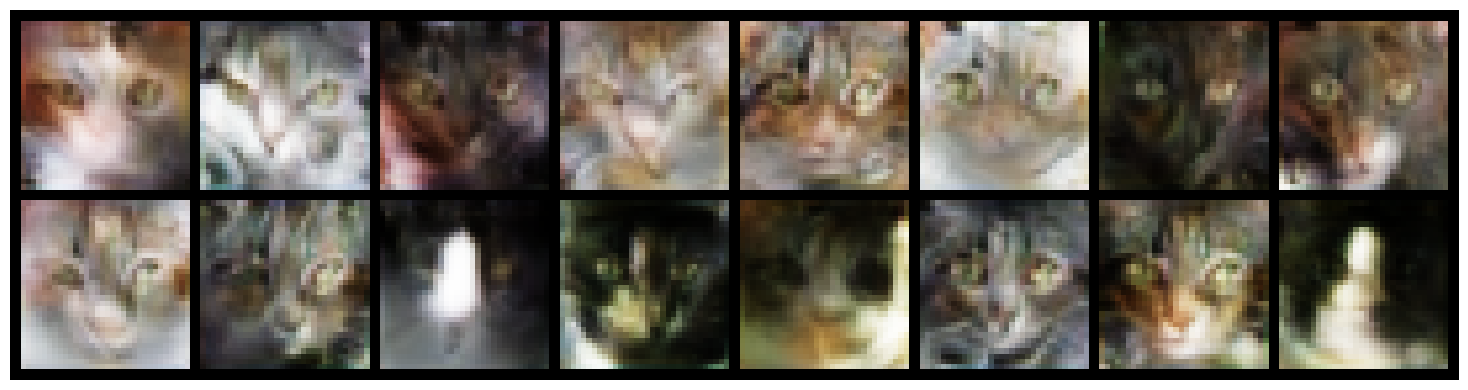

D_loss: 0.5884  G_loss: 2.2137  D(x): 0.749  D(G(z)): 0.161: 100%|█████████▉| 4999/5000 [09:30<00:00,  9.59it/s]

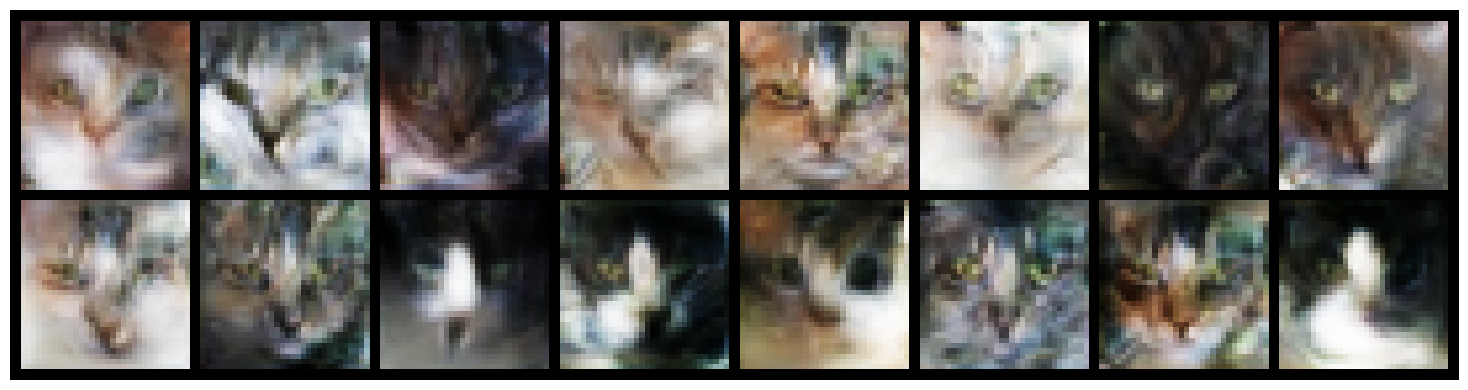

D_loss: 0.5884  G_loss: 2.2137  D(x): 0.749  D(G(z)): 0.161: 100%|██████████| 5000/5000 [09:30<00:00,  8.77it/s]


In [14]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="DCGAN")

for step in pbar:
    real_images = next(train_loader).to(device)

    ########## D Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    with torch.no_grad():
        fake_images = generator(z)

    d_real = discriminator(real_images)
    d_fake = discriminator(fake_images)
    real_loss = criterion(d_real, real_targets)
    fake_loss = criterion(d_fake, fake_targets)

    loss_D = real_loss + fake_loss

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()


    ########## G Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    fake_images = generator(z)
    d_fake = discriminator(fake_images)
    loss_G = criterion(d_fake, real_targets)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)